# Energy Function & Energy Gap (HHNN Eq. 40 & 44)

This notebook shows how to compute the hyperbolic energy function and energy gap step by step using MovieLens data.

## Data used

We need **hyperbolic states** \(z = x + u y\) for each movie to compute energy.
We use:

- `rating.csv` → average rating per movie → **x** (magnitude)
- `genome_scores.csv` → tag relevance per movie → **y** (semantic component)

This maps MovieLens signals into hyperbolic numbers, which we then normalize using Eq. 34 before computing energy.

In [32]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root regardless of where the notebook runs
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data"

# Load ratings and genome scores
ratings_path = data_dir / "rating.csv"
if not ratings_path.exists():
    ratings_path = data_dir / "ratings.csv"

scores_path = data_dir / "genome_scores.csv"
if not scores_path.exists():
    raise FileNotFoundError("genome_scores.csv not found")

ratings_df = pd.read_csv(ratings_path, usecols=["movieId", "rating"])
movie_rating = ratings_df.groupby("movieId")["rating"].mean().rename("avg_rating")

scores_df = pd.read_csv(scores_path, usecols=["movieId", "tagId", "relevance"])
# choose a common tagId for demo
tag_id = int(scores_df["tagId"].mode().iloc[0])
score_slice = scores_df[scores_df["tagId"] == tag_id].set_index("movieId")

merged = movie_rating.to_frame().join(score_slice[["relevance"]], how="inner")
merged = merged.sample(n=200, random_state=42)

# build hyperbolic inputs
x = (merged["avg_rating"] / 5.0).values + 0.1
raw_y = merged["relevance"].values
scale = np.minimum(0.9 * np.abs(x) / (np.abs(raw_y) + 1e-8), 1.0)
y = raw_y * scale
modulus = np.sqrt(np.maximum(x**2 - y**2, 1e-12))

# hyperbolic activation g(z) = z/|z|
A = x / modulus  # real part
B = y / modulus  # unipotent part

print("tagId used:", tag_id)
print("sample count:", len(A))

tagId used: 1
sample count: 200


## Energy function (Eq. 40) and energy gap (Eq. 44)

Paper defines energy for HHNN:

```math
E = \frac{1}{2} \sum_k \sum_{j \ne k} z_k \, w_{kj} \, z_j
```

When neuron \(l\) changes state from \(z_l\) to \(z'_l\), the energy gap is:

```math
\Delta E = (z'_l I_l)_r - (z_l I_l)_r
```

where \(I_l = \sum_{j \ne l} w_{lj} z_j\) and \((\cdot)_r\) is the real part.

In [33]:
# Compute energy and energy gap using hyperbolic states
# Build a small tag-tag weight matrix W from the sample states
K = 8  # use first K states as a tiny HHNN
A_k = A[:K]
B_k = B[:K]

# Hyperbolic product: (a+ub)(c+ud) = (ac+bd) + u(ad+bc)
W_real = np.outer(A_k, A_k) + np.outer(B_k, B_k)
W_unip = np.outer(A_k, B_k) + np.outer(B_k, A_k)

# Build z for the same K units
z_real = A_k
z_unip = B_k

# Energy (Eq. 40) real part
E_real = 0.0
for k in range(K):
    for j in range(K):
        if j == k:
            continue
        # z_k * w_kj * z_j (hyperbolic multiply)
        a1, b1 = z_real[k], z_unip[k]
        a2, b2 = W_real[k, j], W_unip[k, j]
        a3, b3 = z_real[j], z_unip[j]
        # (a1+ub1)(a2+ub2) = (a1a2+b1b2) + u(a1b2+b1a2)
        r12 = a1 * a2 + b1 * b2
        u12 = a1 * b2 + b1 * a2
        # (r12+u u12)(a3+u b3)
        r123 = r12 * a3 + u12 * b3
        E_real += r123

E_real *= 0.5
print("Energy E (real part):", E_real)

# Energy gap (Eq. 44) for flipping one unit l
l = 0
# Input I_l = sum_{j != l} w_lj z_j
I_real = 0.0
I_unip = 0.0
for j in range(K):
    if j == l:
        continue
    a2, b2 = W_real[l, j], W_unip[l, j]
    a3, b3 = z_real[j], z_unip[j]
    r23 = a2 * a3 + b2 * b3
    u23 = a2 * b3 + b2 * a3
    I_real += r23
    I_unip += u23

# propose new state z'_l by negating unipotent part
z_prime_real = z_real[l]
z_prime_unip = -z_unip[l]

# (z' I_l)_r - (z I_l)_r
z_r, z_u = z_real[l], z_unip[l]

# z I_l
zI_r = z_r * I_real + z_u * I_unip
# z' I_l
zIprime_r = z_prime_real * I_real + z_prime_unip * I_unip

DeltaE = zIprime_r - zI_r
print("Energy gap ΔE (real part):", DeltaE)


Energy E (real part): 28.736168157136753
Energy gap ΔE (real part): -0.15728784507733096


## Visualization

We visualize the distribution of energy contributions and the energy gap for a small subset.

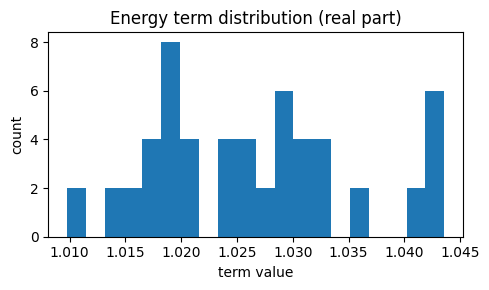

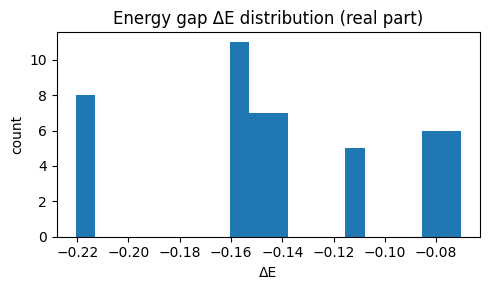

In [34]:
# Visualize energy contributions for each pair (k,j)
K = 8
A_k = A[:K]
B_k = B[:K]

pair_terms = []
for k in range(K):
    for j in range(K):
        if j == k:
            continue
        # contribution to energy (real part)
        a1, b1 = A_k[k], B_k[k]
        a2, b2 = W_real[k, j], W_unip[k, j]
        a3, b3 = A_k[j], B_k[j]
        r12 = a1 * a2 + b1 * b2
        u12 = a1 * b2 + b1 * a2
        r123 = r12 * a3 + u12 * b3
        pair_terms.append(r123)

plt.figure(figsize=(5, 3))
plt.hist(pair_terms, bins=20)
plt.title("Energy term distribution (real part)")
plt.xlabel("term value")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# Visualize energy gap for multiple random flips
np.random.seed(42)
energy_gaps = []
for l in np.random.choice(range(K), size=50, replace=True):
    I_real = 0.0
    I_unip = 0.0
    for j in range(K):
        if j == l:
            continue
        a2, b2 = W_real[l, j], W_unip[l, j]
        a3, b3 = A_k[j], B_k[j]
        r23 = a2 * a3 + b2 * b3
        u23 = a2 * b3 + b2 * a3
        I_real += r23
        I_unip += u23

    z_r, z_u = A_k[l], B_k[l]
    z_prime_r, z_prime_u = z_r, -z_u
    zI_r = z_r * I_real + z_u * I_unip
    zIprime_r = z_prime_r * I_real + z_prime_u * I_unip
    energy_gaps.append(zIprime_r - zI_r)

plt.figure(figsize=(5, 3))
plt.hist(energy_gaps, bins=20)
plt.title("Energy gap ΔE distribution (real part)")
plt.xlabel("ΔE")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Step B — Paper formulas to data

We use the RBM conditional probability (paper formula):

```math
P(h_j = 1 \mid v) = \sigma((vW)_j + c_j)
```

Here, `v` is the user's visible vector (items), and `h` is the hidden feature vector.

In [35]:
# Compute hidden features for one user
rbm = RBM(n_visible=train_matrix.shape[1], n_hidden=128, k=5)

v0 = torch.from_numpy(train_matrix[user_idx].toarray()).float()
h_prob, _ = rbm.sample_h(v0)

# Hidden features = probabilities of hidden units
hidden_values = h_prob.squeeze().detach().cpu().numpy()
print("hidden feature vector shape:", hidden_values.shape)

# Top activated hidden units
top_h = hidden_values.argsort()[::-1][:10]
print("top hidden unit indices:", top_h)
print("top hidden activations:", hidden_values[top_h])

NameError: name 'RBM' is not defined

## Step C — Interpreting hidden features

A hidden unit can be interpreted as a latent preference pattern. We can inspect which items connect most strongly to a chosen hidden unit by ranking the weights in that column.

In [ ]:
# Inspect items most associated with one hidden unit
id_to_item = {idx: mid for mid, idx in item_id_map.items()}
movie_candidates = ["movies.csv", "movie.csv"]
movie_path = None
for name in movie_candidates:
    path = os.path.join("data", name)
    if os.path.exists(path):
        movie_path = path
        break

movie_titles = {}
if movie_path:
    movie_df = pd.read_csv(movie_path, usecols=["movieId", "title"])
    movie_titles = dict(zip(movie_df["movieId"].astype(int), movie_df["title"]))

h_idx = int(top_h[0])
weights = rbm.W[:, h_idx].detach().cpu().numpy()
item_rank = weights.argsort()[::-1][:10]

print("hidden unit:", h_idx)
for rank, item_idx in enumerate(item_rank, start=1):
    movie_id = id_to_item[item_idx]
    title = movie_titles.get(movie_id, "UNKNOWN_TITLE")
    print(f"{rank:02d}. movieId={movie_id} | {title}")

In [ ]:
# 3) Sparsity and basic statistics
n_users, n_items = train_matrix.shape
interaction_count = train_matrix.nnz
sparsity = 1.0 - interaction_count / (n_users * n_items)
print("n_users:", n_users)
print("n_items:", n_items)
print("interactions:", interaction_count)
print("sparsity:", round(sparsity, 6))

In [ ]:
# 5) One Contrastive Divergence step with explicit stats
v_batch = torch.from_numpy(train_matrix[:128].toarray()).float()

h0_prob, _ = rbm.sample_h(v_batch)
vk_prob, hk_prob = rbm.gibbs_sampling(v_batch, rbm.k)

pos = (v_batch.t() @ h0_prob) / v_batch.size(0)
neg = (vk_prob.t() @ hk_prob) / v_batch.size(0)

print("pos grad mean:", pos.mean().item())
print("neg grad mean:", neg.mean().item())
print("pos-neg mean:", (pos - neg).mean().item())

loss = torch.nn.functional.binary_cross_entropy(vk_prob, v_batch, reduction="mean").item()
print("CD step reconstruction loss:", loss)

# Apply the actual CD-k update
_ = rbm.contrastive_divergence(v_batch, lr=0.01)

In [ ]:
# 6) Mini training: show loss curve (short)
losses = []
for epoch in range(3):
    batch_losses = []
    for start in range(0, n_users, 256):
        v0 = torch.from_numpy(train_matrix[start : start + 256].toarray()).float()
        batch_losses.append(rbm.contrastive_divergence(v0, lr=0.01))
    losses.append(float(np.mean(batch_losses)))
    print(f"epoch={epoch+1}, loss={losses[-1]:.6f}")

plt.figure(figsize=(5, 3))
plt.plot(np.arange(1, len(losses) + 1), losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("RBM Loss Curve (mini)")
plt.tight_layout()
plt.show()

In [ ]:
# 7) Inference with movie titles
movie_candidates = ["movies.csv", "movie.csv"]
movie_path = None
for name in movie_candidates:
    path = os.path.join("data", name)
    if os.path.exists(path):
        movie_path = path
        break

movie_titles = {}
if movie_path:
    movie_df = pd.read_csv(movie_path, usecols=["movieId", "title"])
    movie_titles = dict(zip(movie_df["movieId"].astype(int), movie_df["title"]))

user_id = list(data["user_id_map"].keys())[0]
user_idx = data["user_id_map"][user_id]
id_to_item = {idx: mid for mid, idx in data["item_id_map"].items()}

v0 = torch.from_numpy(train_matrix[user_idx].toarray()).float()
with torch.no_grad():
    scores = rbm.reconstruct(v0).cpu().numpy().ravel()

seen_items = set(train_matrix[user_idx].indices.tolist())
scores[list(seen_items)] = -np.inf
k = 10
topk = np.argpartition(-scores, k - 1)[:k]
topk = topk[np.argsort(-scores[topk])]

print(f"Top-{k} for user_id={user_id}:")
for rank, idx in enumerate(topk.tolist(), start=1):
    movie_id = id_to_item[idx]
    title = movie_titles.get(movie_id, "UNKNOWN_TITLE")
    print(f"{rank:02d}. movieId={movie_id} | {title}")